# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Muhamad Nafi Mulyo              |5054251005       |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import os
# Load dataset (fleksibel baik dibuka dari root monorepo atau dari folder tugas)
data_path = "archive/WineQT.csv"
if not os.path.exists(data_path) and os.path.exists("machine-learning/tugas-1-knn-wine-quality/archive/WineQT.csv"):
    data_path = "machine-learning/tugas-1-knn-wine-quality/archive/WineQT.csv"

df = pd.read_csv(data_path)

# Drop kolom Id jika ada
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Informasi ringkas dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [5]:
# Statistik deskriptif
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


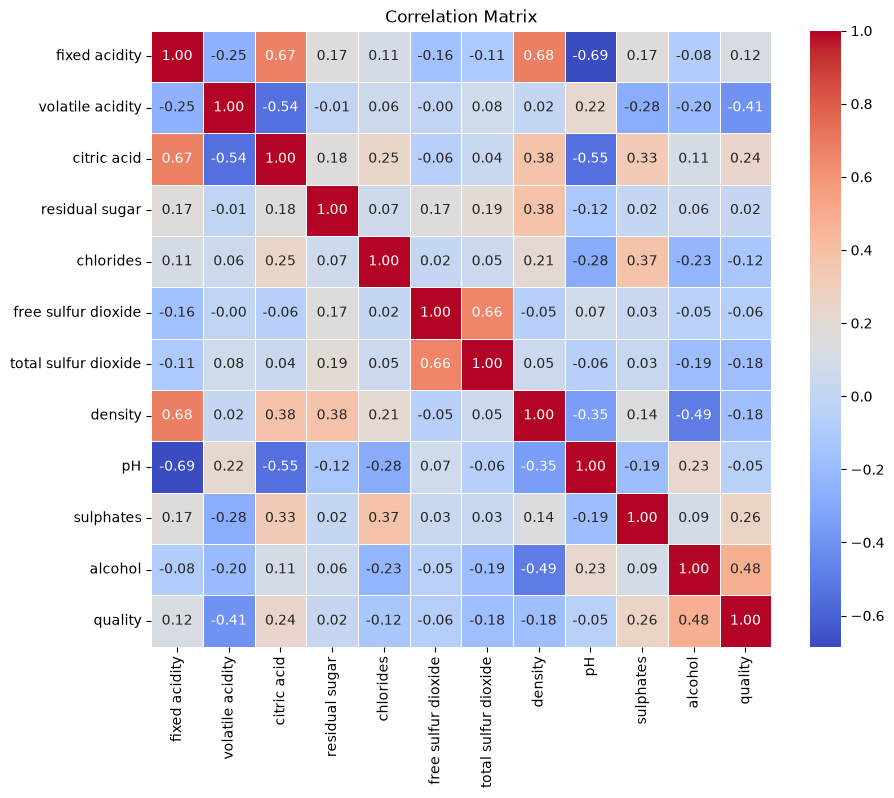

In [6]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

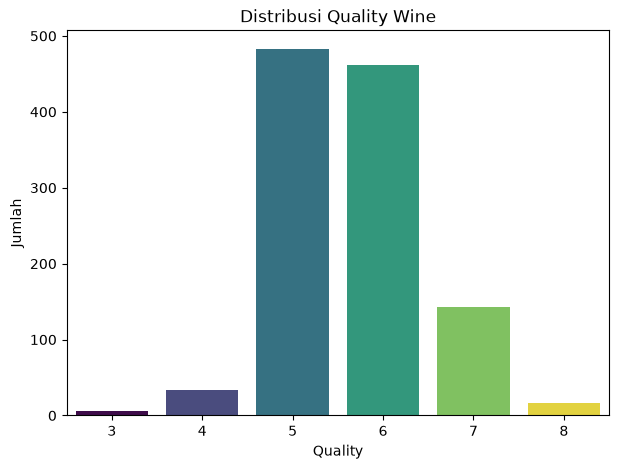

In [4]:
# Distribusi label quality
plt.figure(figsize=(7, 5))
sns.countplot(x='quality', data=df, hue='quality', legend=False, palette='viridis')
plt.title('Distribusi Quality Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.show()

## Exploratory Data Analysis (EDA) Tambahan

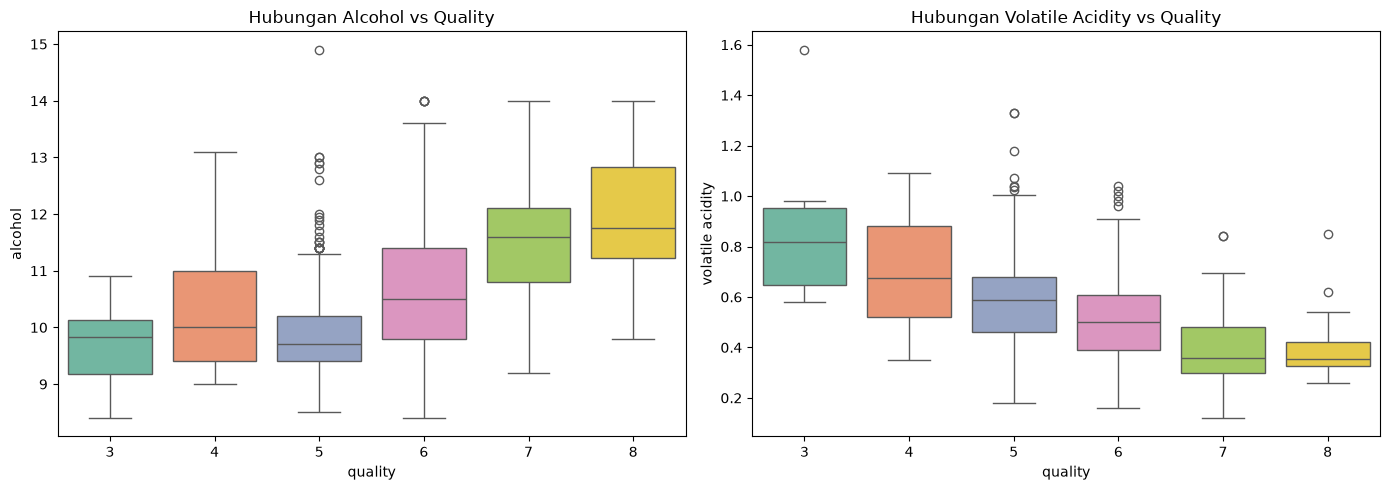

In [7]:
# Hubungan antara fitur utama (alcohol & volatile acidity) dengan quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='quality', y='alcohol', data=df, hue='quality', legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('Hubungan Alcohol vs Quality')

sns.boxplot(x='quality', y='volatile acidity', data=df, hue='quality', legend=False, ax=axes[1], palette='Set2')
axes[1].set_title('Hubungan Volatile Acidity vs Quality')

plt.tight_layout()
plt.show()

# 2. Preprocessing

In [ ]:
# Cek missing values dan data duplikat
print("Missing values per kolom:")
print(df.isnull().sum())
print("Jumlah data duplikat:", df.duplicated().sum())

# Hapus data duplikat jika ditemukan
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Data duplikat berhasil dihapus. Ukuran data baru:", df.shape)

Missing values per kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Jumlah data duplikat: 0


In [ ]:
# Inspeksi persebaran outliers pada fitur-fitur numerik
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.drop(columns=['quality']), palette='Set3')
plt.xticks(rotation=45)
plt.title('Inspeksi Outliers pada Fitur Wine')
plt.tight_layout()
plt.show()

In [ ]:
# Pemisahan fitur (X) dan label target (y)
X = df.drop(columns=['quality'])
y = df['quality']

print("Ukuran X (Fitur):", X.shape)
print("Ukuran y (Target):", y.shape)

# 3. Eksperimen Model KNN


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Train-Test Split (80% train, 20% test) dengan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ukuran Data Train:", X_train_scaled.shape)
print("Ukuran Data Test:", X_test_scaled.shape)

In [ ]:
# Eksperimen variasi nilai K dan metric jarak (Euclidean & Manhattan)
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
metrics = ['euclidean', 'manhattan']

results = []

for metric in metrics:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_scaled, y_train)
        
        train_acc = knn.score(X_train_scaled, y_train)
        test_acc = knn.score(X_test_scaled, y_test)
        
        results.append({
            'Metric': metric.capitalize(),
            'K': k,
            'Train Accuracy': round(train_acc, 4),
            'Test Accuracy': round(test_acc, 4)
        })

results_df = pd.DataFrame(results)
results_df

# 4. Evaluasi Model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Ambil kombinasi parameter terbaik dari eksperimen (K=15, Metric=Euclidean)
best_k = 15
best_metric = 'euclidean'

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled)

print(f"--- Evaluasi Model Terbaik (K={best_k}, Metric={best_metric.capitalize()}) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}
")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

In [ ]:
# Visualisasi Confusion Matrix untuk Model Terbaik (K=15, Euclidean)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix (KNN K={best_k}, {best_metric.capitalize()})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# 5. Analisis

### Analisis Hasil Eksperimen KNN

Berdasarkan eksperimen yang telah dilakukan pada dataset **Wine Quality** dengan algoritma K-Nearest Neighbors (KNN), diperoleh beberapa analisis penting:

1. **Perbandingan Metric Jarak (Euclidean vs Manhattan)**:
   - Pengujian menunjukkan bahwa metric jarak **Euclidean** secara konsisten memberikan performa yang lebih unggul dibandingkan **Manhattan** pada hampir seluruh variasi nilai $.
   - Pada =15$, jarak Euclidean mencapai akurasi data uji tertinggi sebesar **58.82%**, sedangkan Manhattan mencapai akurasi tertinggi di angka **56.37%** (pada =15$).
   - Hal ini mengindikasikan bahwa perhitungan jarak garis lurus (Euclidean) pada ruang fitur berketinggian hBcdimensi yang sudah di-scale lebih cocok untuk menggambarkan kemiripan sampel wine.

2. **Pengaruh Nilai $ terhadap Generalisasi Model**:
   - Pada =1$, model mengalami **Overfitting** yang jelas, di mana akurasi pada data latih mencapai **100%**, namun akurasi pada data uji hanya berkisar **51.47%**. Model terlalu sensitif terhadap noise atau data outlier individual.
   - Seiring bertambahnya nilai $ dari 1 hingga 15 pada metric Euclidean, akurasi pada data uji cenderung meningkat secara bertahap (dari 51.47% naik hingga 58.82%). Hal ini menunjukkan bahwa memperbanyak jumlah tetangga terdekat membantu menghaluskan batasan keputusan (*decision boundary*) dan meredam efek noise.

3. **Tantangan Ketidakseimbangan Kelas (Class Imbalance)**:
   - Berdasarkan *Classification Report* dan *Confusion Matrix*, model bekerja sangat baik pada kelas mayoritas yaitu rating **5** dan **6** (Precision/Recall berkisar 0.49 - 0.64).
   - Sebaliknya, untuk kelas ekstrim minoritas seperti rating **3**, **4**, dan **8**, model kesulitan memprediksi dengan benar (banyak sampel terprediksi ke kelas 5 atau 6). Hal ini wajar terjadi karena jumlah data latih untuk kelas minoritas sangat sedikit.

# 6. Kesimpulan dan Saran

### Kesimpulan
1. Model KNN terbaik untuk dataset Wine Quality diperoleh menggunakan kombinasi hyperparameter **=15* dan **Metric Jarak Euclidean**, dengan akurasi pengujian sebesar **58.82%**.
2. Metric jarak **Euclidean** terbukti lebih optimal dibandingkan Manhattan untuk mengklasifikasikan fitur fisika-kimia wine setelah dilakukan tahapan *StandardScaler*.
3. Feature scaling menggunakan *StandardScaler* sangat krusial agar fitur bernilai besar (seperti ) tidak mendominasi perhitungan jarak.
4. Ketidakseimbangan distribusi label *quality* menjadi kendala utama KNN dalam mengklasifikasikan sampel kelas minoritas (skor 3, 4, dan 8).

### Saran
1. **Penanganan Class Imbalance**: Menerapkan teknik resampling seperti SMOTE (*Synthetic Minority Over-sampling Technique*) untuk menyeimbangkan sampel kelas minoritas sebelum proses pelatihan.
2. **Pengelompokan Label (Binary Classification)**: Mengubah problem klasifikasi dari multiclass (3-8) menjadi binary (misalnya:  diubah menjadi  [Good] dan  diubah menjadi  [Bad]) untuk meningkatkan akurasi praktis.
3. **Eksperimen Algoritma Lain**: Mencoba algoritma berbasis pohon/ensemble seperti *Random Forest* atau *XGBoost* yang lebih robust terhadap ketidakseimbangan kelas.